1. Configuração do Ambiente e Base de Dados


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}
df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)


2. Roteiro de Tarefas
Parte 1: Distribuições e Contagens (Básico)
Crie um gráfico de barras para exibir a contagem de usuários por tipo de plano.
Utilize a função countplot e ordene as barras pela frequência.
Analise a distribuição da variável idade utilizando um histplot. Adicione a curva de densidade (KDE) para suavizar a visualização.


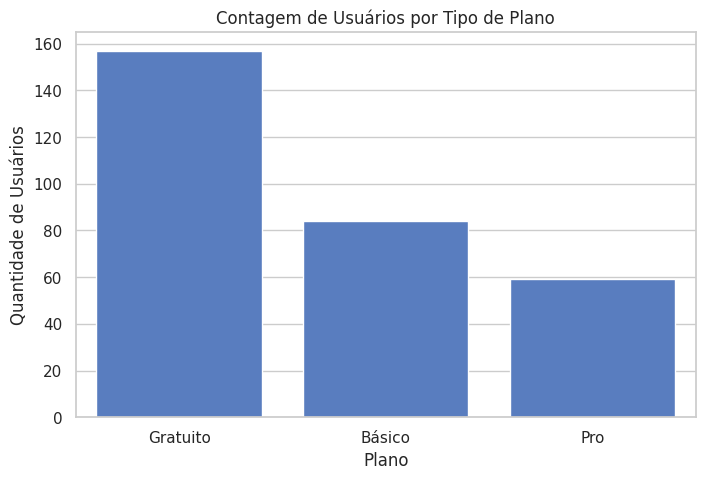

In [ ]:
# 1. Contagem de usuários por tipo de plano (countplot ordenado)
plt.figure(figsize=(8, 5))
ordem_planos = df_sistema['plano'].value_counts().index

sns.countplot(
    data=df_sistema,
    x='plano',
    order=ordem_planos
)

plt.title('Contagem de Usuários por Tipo de Plano')
plt.xlabel('Plano')
plt.ylabel('Quantidade de Usuários')
plt.show()

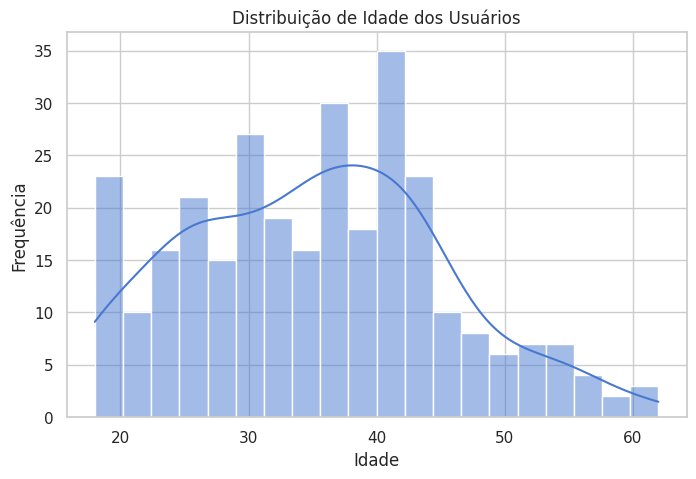

In [ ]:
# 2. Distribuição da idade (histplot com KDE)
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_sistema,
    x='idade',
    kde=True,
    bins=20
)

plt.title('Distribuição de Idade dos Usuários')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

Parte 2: Relações Categóricas e Numéricas (Intermediário)
3. Construa um boxplot para comparar a distribuição do tempo_uso_horas entre os diferentes tipos de plano.
4. Crie um violinplot cruzando o plano com a satisfacao. Esse gráfico ajudará a entender não apenas a mediana, mas a densidade das notas dadas pelos clientes de cada plano.


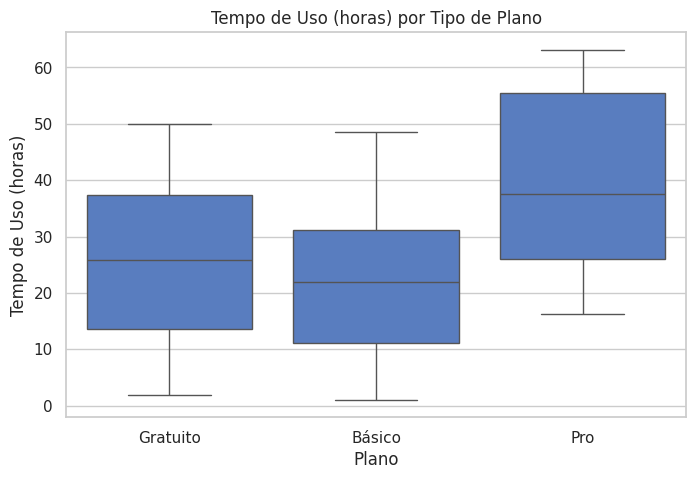

In [ ]:
# 3. Boxplot: tempo_uso_horas por plano
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_sistema,
    x='plano',
    y='tempo_uso_horas',
    order=ordem_planos
)

plt.title('Tempo de Uso (horas) por Tipo de Plano')
plt.xlabel('Plano')
plt.ylabel('Tempo de Uso (horas)')
plt.show()

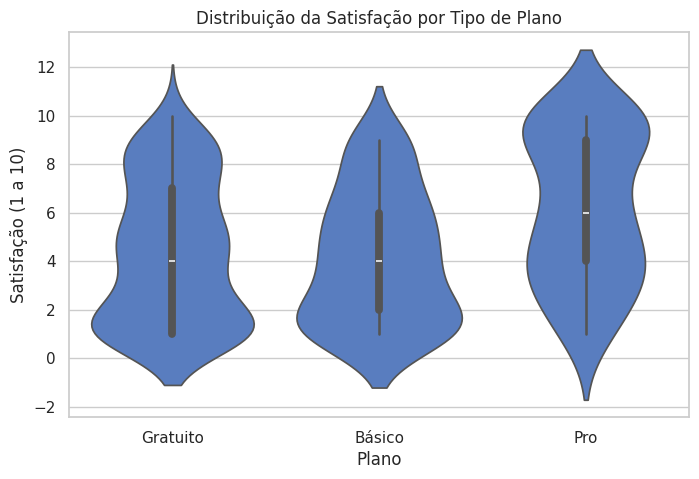

In [ ]:
# 4. Violinplot: satisfacao por plano
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df_sistema,
    x='plano',
    y='satisfacao',
    order=ordem_planos
)

plt.title('Distribuição da Satisfação por Tipo de Plano')
plt.xlabel('Plano')
plt.ylabel('Satisfação (1 a 10)')
plt.show()

Parte 3: Correlações e Análise Multivariada (Avançado)
5. Utilize um scatterplot para investigar a relação entre tempo_uso_horas (eixo X) e satisfacao (eixo Y). Utilize o parâmetro hue para colorir os pontos de acordo com o plano e size para variar o tamanho dos pontos com base nos bugs_reportados.
6. Calcule a matriz de correlação de Pearson apenas para as variáveis numéricas do DataFrame e visualize-a utilizando um heatmap. Configure a paleta de cores para divergir do centro (ex: 'coolwarm' ou 'vlag') e ative as anotações numéricas (annot=True).
7. (Bônus) Gere um pairplot englobando as variáveis tempo_uso_horas, bugs_reportados e satisfacao, utilizando o plano como hue.


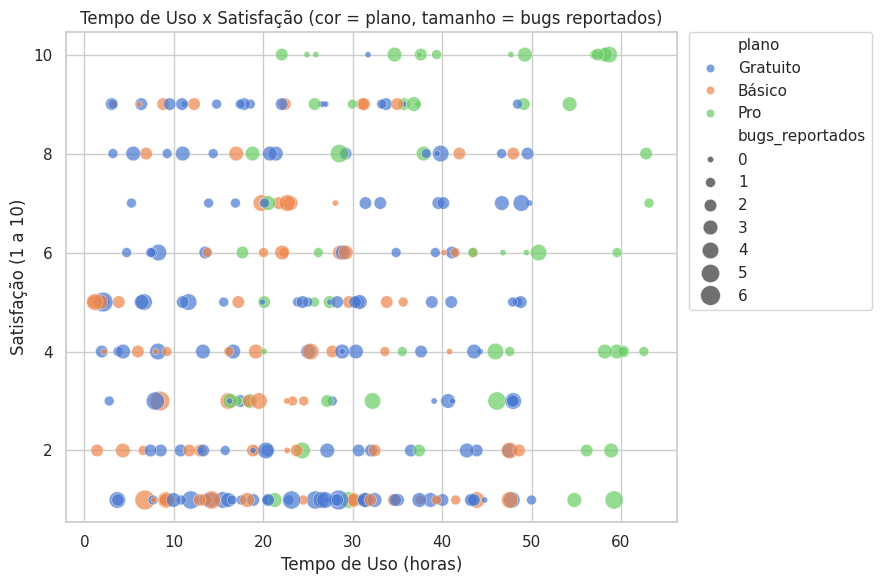

In [ ]:
# 5. Scatterplot: tempo_uso_horas x satisfacao, hue=plano, size=bugs_reportados
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_sistema,
    x='tempo_uso_horas',
    y='satisfacao',
    hue='plano',
    hue_order=ordem_planos,
    size='bugs_reportados',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Tempo de Uso x Satisfação (cor = plano, tamanho = bugs reportados)')
plt.xlabel('Tempo de Uso (horas)')
plt.ylabel('Satisfação (1 a 10)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

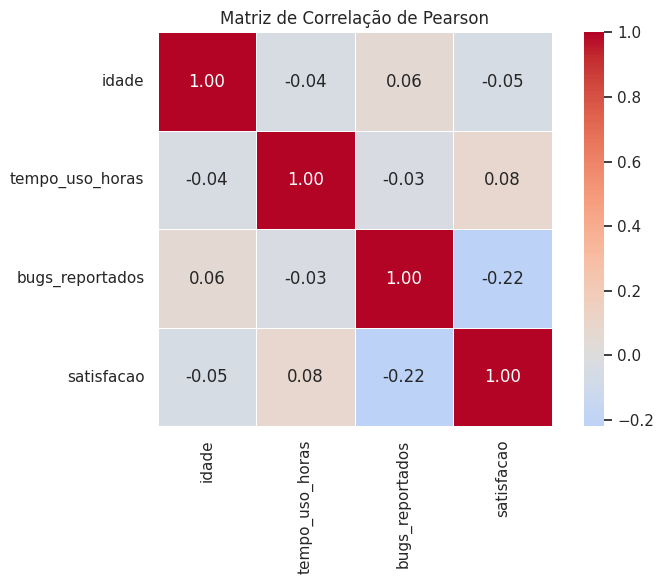

In [ ]:
# 6. Matriz de correlação de Pearson (heatmap)
colunas_numericas = df_sistema.select_dtypes(include=np.number).columns
matriz_corr = df_sistema[colunas_numericas].corr(method='pearson')

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Matriz de Correlação de Pearson')
plt.tight_layout()
plt.show()

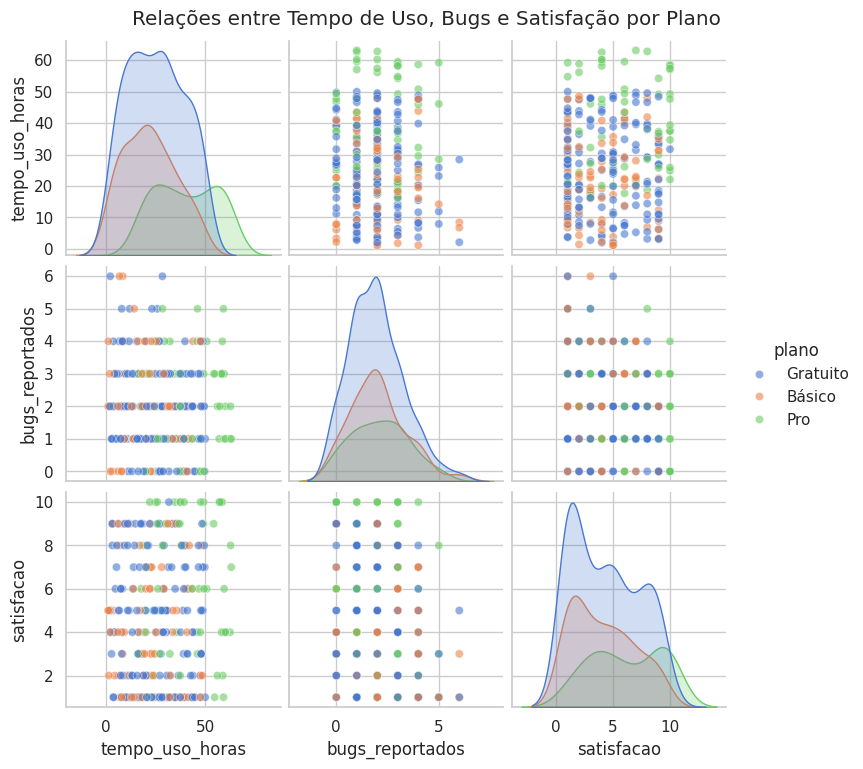

In [ ]:
# 7. (Bônus) Pairplot: tempo_uso_horas, bugs_reportados, satisfacao (hue=plano)
pairplot_fig = sns.pairplot(
    df_sistema,
    vars=['tempo_uso_horas', 'bugs_reportados', 'satisfacao'],
    hue='plano',
    hue_order=ordem_planos,
    palette='muted',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

pairplot_fig.fig.suptitle('Relações entre Tempo de Uso, Bugs e Satisfação por Plano', y=1.02)
plt.show()